<a href="https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/fields/01_how_models_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Field 1 · How models learn · taste project*

# How does a network get better from examples?

> **In short**
>
> **How does a network get better from examples?**
>
> It measures how wrong it is, works out which way each weight should move to be less wrong, and moves every weight a small step that way. You will build the part that works out "which way" yourself, in about 100 lines.

## Where you'll end up

By the end of this notebook you will have:

1. **A tiny engine that calculates slopes automatically** (about 100 lines of Python).
2. **A network built on top of it** that learns to read handwritten digits, like the ones below.
3. **The same network in PyTorch**, in about 20 lines, and a check that both engines agree.

Time: about one weekend if you do the exercises. Running every cell takes about 5 minutes.

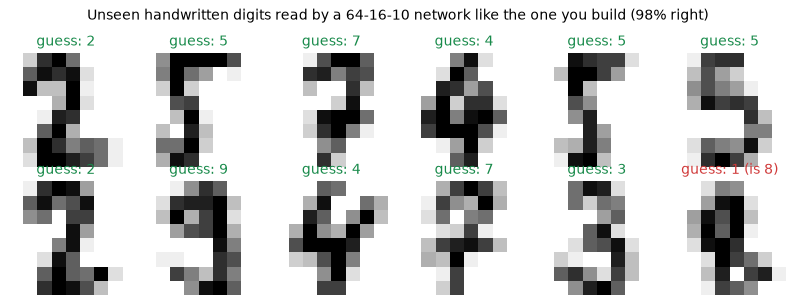

## How to use this notebook

- Run each grey code cell with **Shift + Enter**, top to bottom.
- 🤔 **Predict first** boxes ask you to guess before you run. The answer is one click away.
- 🐍 **Python notes** explain Python as it comes up. You can program already; these notes cover what Python does differently.
- Solutions to exercises are in collapsed cells. In Colab, double-click a solution's title to open it.

## 1. The problem

Here are 1,797 small images of handwritten digits. Each is 8 × 8 pixels. Each pixel is a number from 0 (white) to 16 (black).

You want a program that looks at the 64 numbers and says which digit it is.
Nobody can write that rule by hand.
Instead, you will build a function with many adjustable numbers, called **weights**, and adjust them until the answers come out right.

The hard part: with hundreds of weights, **which way should each one move?** That is what this notebook builds.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()            # ships with scikit-learn, no download
X = digits.data / 16.0            # 1797 rows of 64 numbers, scaled to 0..1
y = digits.target                 # the right answers, 0 to 9
print("images:", X.shape, " answers:", y.shape)

fig, axes = plt.subplots(1, 8, figsize=(10, 1.8))
for ax, i in zip(axes, range(8)):
    ax.imshow(digits.images[i], cmap="gray_r")
    ax.set_title(f"answer {y[i]}")
    ax.axis("off")
plt.show()

🐍 **Python notes**
- `import numpy as np` loads the numpy library under the short name `np`.
- `X.shape` is `(1797, 64)`: 1,797 rows, 64 columns. `X / 16.0` divides every number at once; no loop needed.
- `zip(axes, range(8))` walks two lists side by side.
- `f"answer {y[i]}"` is an **f-string**: the part in braces is replaced by its value.

## 2. Which way should a number move? Nudge it and see

Start small. Here is a function of one number:

$$f(a) = a^2 + 3a$$

At $a = 2$, $f = 10$. If you nudge $a$ up a tiny bit, does $f$ go up or down, and how fast?

### 🤔 Predict first

At $a = 2$, if $a$ goes up by 0.001, **roughly how much does $f$ change?** (Guess before running.)

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

About **0.007**. The slope at $a = 2$ is 7: $f$ changes about 7 times as much as $a$. Run the next cell to see it.

</details>

In [ ]:
def f(a):
    return a**2 + 3*a

h = 0.001
a = 2.0
print("f(a)        =", f(a))
print("f(a + h)    =", f(a + h))
print("change / h  =", (f(a + h) - f(a)) / h)

**What you see:** nudging $a$ by $h$ changes $f$ by about $7h$. The ratio, about 7, is how steeply $f$ rises at $a = 2$.

**What it means:** if you want $f$ smaller, move $a$ *down*; the bigger the ratio, the more it matters.

**What it's called:** that ratio, as $h$ shrinks toward 0, is the **derivative** of $f$ with respect to $a$, written $\dfrac{df}{da}$.
For $f = a^2 + 3a$, calculus gives the formula $\dfrac{df}{da} = 2a + 3$, which is 7 at $a = 2$.

**Why not always nudge?** A network has thousands of weights. Nudging each one separately means thousands of extra runs per step.
The engine you build next gets *every* slope from one run forwards and one run backwards.

## 3. A number that records where it came from

To get slopes automatically, each number must record **which numbers made it, and how**.
Then you can walk backwards from the answer to every input.

Here is the start of that number type. It is a Python **class**.

In [ ]:
class Value:
    def __init__(self, data, children=(), op=""):
        self.data = data          # the number itself
        self.grad = 0.0           # slope of the final answer with respect to this number (filled in later)
        self._children = children # the Values that made this one
        self._op = op             # how they made it: "+", "*", ...
        self._backward = lambda: None   # how to pass slopes back to the children (set below)

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        return out

a = Value(2.0)
b = Value(-3.0)
c = a * b + a
print(c, " made by", c._op, "from", c._children)

🐍 **Python notes**
- `class Value:` defines a new type. `__init__` runs when you write `Value(2.0)`. `self` is the object itself (like `this` in Java or C++).
- Methods with double underscores are **operator overloading**: `a * b` calls `a.__mul__(b)`; `a + b` calls `a.__add__(b)`; `print(a)` uses `__repr__`.
- `lambda: None` is a tiny function with no name that does nothing. Each operation will replace it with a real one.
- `isinstance(other, Value)` lets you write `a + 1`: plain numbers get wrapped in a `Value`.

**What you see:** `c` is a `Value` that records it was made by `+` from two other `Value`s. Each of those records its own parents. Together they form a **graph** of the calculation.

In [ ]:
def show(v, indent=0):
    """Print the calculation graph, answer at the top, inputs at the bottom."""
    label = f"{v._op} " if v._op else ""
    print("    " * indent + f"{label}data={v.data:.3f}  grad={v.grad:.3f}")
    for child in v._children:
        show(child, indent + 1)

show(c)

**What it's called:** a picture like this, with numbers as points and arrows from inputs to outputs, is a **computation graph**.
Arrows only go one way and never loop back, so it is a **directed acyclic graph** (DAG).
Your function `show` calls itself on each child; a function that calls itself is **recursive**.

## 4. Passing slopes backwards: the chain rule

Take one `*` step: $out = a \times b$.

- Nudge $a$ by $h$: $out$ changes by $b \times h$. So the slope of $out$ with respect to $a$ is $b$.
- Likewise, the slope with respect to $b$ is $a$.

And one `+` step: $out = a + b$. Nudge either by $h$ and $out$ changes by $h$. Both slopes are 1.

Now chain them. Suppose the final answer $L$ depends on $out$ with slope $\dfrac{dL}{d\,out}$ (already known).
A nudge to $a$ changes $out$ by $b\,h$, which changes $L$ by $\dfrac{dL}{d\,out} \times b\,h$. So:

$$\frac{dL}{da} = \frac{dL}{d\,out} \times \frac{d\,out}{da}$$

**Multiply the slopes along the path.** That rule is the **chain rule**.
If $a$ is used in two places, its slopes from both paths **add up**.

### 🤔 Predict first

For `c = a * b + a` with `a = 2`, `b = -3`: **what is $\dfrac{dc}{da}$?** (Hint: $a$ is used twice.)

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

Through the `*`: slope $b = -3$. Through the `+` directly: slope 1. They add: $-3 + 1 = $ **$-2$**. Check: nudge $a$ to 2.001 and $c$ goes from $-4$ to $-4.002$.

</details>

Now teach `Value` the backward step for each operation. Each `_backward` takes `out.grad` and adds its share to the children's `grad`.
(`+=`, not `=`, so that slopes from several paths add up.)

In [ ]:
class Value:
    def __init__(self, data, children=(), op=""):
        self.data = data
        self.grad = 0.0
        self._children = children
        self._op = op
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += 1.0 * out.grad       # d(out)/d(self) = 1
            other.grad += 1.0 * out.grad      # d(out)/d(other) = 1
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad   # d(out)/d(self) = other
            other.grad += self.data * out.grad   # d(out)/d(other) = self
        out._backward = _backward
        return out

🐍 **Python note:** `_backward` is defined *inside* `__add__`, so it can see `self`, `other` and `out` even after `__add__` has finished.
A function that keeps access to the variables around it is a **closure**.

### In which order should the backward steps run?

A step can only pass slopes back once its own `grad` is complete, so **every step that uses a value must run before that value's step**.
That means: list the graph so each value comes after everything it was made from, then run the list in reverse.

In [ ]:
def build_order(root):
    """List every Value so that each one comes after the Values it was made from."""
    order, seen = [], set()
    def visit(v):
        if v in seen:
            return
        seen.add(v)
        for child in v._children:
            visit(child)
        order.append(v)          # added only after all its children
    visit(root)
    return order

def backward(root):
    root.grad = 1.0              # dL/dL = 1
    for v in reversed(build_order(root)):
        v._backward()

a = Value(2.0); b = Value(-3.0)
c = a * b + a
backward(c)
print("dc/da =", a.grad, "  dc/db =", b.grad)

**What it's called:** an ordering where every item comes after the items it depends on is a **topological sort**.
`build_order` finds one with a depth-first search: visit the children first, then add yourself.
Running `_backward` in reverse topological order is **backpropagation**.

`dc/da = -2` matches your prediction. `dc/db = 2`: nudge $b$ up and $c$ rises twice as fast, because $c = ab + a$ and $a = 2$.

## 5. The full engine: about 100 lines

A network needs a few more operations: powers, `exp`, `log`, division, and a "bend" function.
Here is the complete `Value` class. Read the `_backward` of each one: it is the derivative rule from calculus, times `out.grad`.

In [ ]:
import math

class Value:
    """A number that records how it was made, so slopes can flow back through it."""

    def __init__(self, data, children=(), op=""):
        self.data = float(data)
        self.grad = 0.0
        self._children = children
        self._op = op
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data:.4f}, grad={self.grad:.4f})"

    @staticmethod
    def wrap(x):
        return x if isinstance(x, Value) else Value(x)

    def __add__(self, other):
        other = Value.wrap(other)
        out = Value(self.data + other.data, (self, other), "+")
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = Value.wrap(other)
        out = Value(self.data * other.data, (self, other), "*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, k):                      # k is a plain number
        out = Value(self.data ** k, (self,), f"**{k}")
        def _backward():
            self.grad += k * self.data ** (k - 1) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), "exp")
        def _backward():
            self.grad += out.data * out.grad     # d/dx e^x = e^x
        out._backward = _backward
        return out

    def log(self):
        out = Value(math.log(self.data), (self,), "log")
        def _backward():
            self.grad += (1 / self.data) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        t = math.tanh(self.data)
        out = Value(t, (self,), "tanh")
        def _backward():
            self.grad += (1 - t * t) * out.grad
        out._backward = _backward
        return out

    # the rest are built from the operations above
    def __neg__(self):            return self * -1
    def __sub__(self, other):     return self + (-Value.wrap(other))
    def __truediv__(self, other): return self * Value.wrap(other) ** -1
    def __radd__(self, other):    return self + other      # lets you write 2 + v
    def __rmul__(self, other):    return self * other      # lets you write 2 * v
    def __rsub__(self, other):    return Value.wrap(other) - self
    def __rtruediv__(self, other): return Value.wrap(other) / self

    def backward(self):
        order, seen = [], set()
        def visit(v):
            if v not in seen:
                seen.add(v)
                for c in v._children:
                    visit(c)
                order.append(v)
        visit(self)
        self.grad = 1.0
        for v in reversed(order):
            v._backward()

🐍 **Python notes**
- `@staticmethod` marks a method that doesn't need `self`; call it as `Value.wrap(x)`.
- `__radd__` handles `2 + v` (the plain number is on the left), so Python asks `v` to do it.
- Long recursive graphs can hit Python's recursion limit; the next cell raises it.

### Does it match nudging?

A test you should always run: compare the engine's slopes with the slow nudge method.

In [ ]:
import sys
sys.setrecursionlimit(100_000)

def L_of(a, b):
    return ((a * b).tanh() + (a / b) ** 2).exp()

a, b = Value(0.7), Value(-1.3)
L = L_of(a, b)
L.backward()

h = 1e-6
nudge_a = (L_of(Value(0.7 + h), Value(-1.3)).data - L.data) / h
nudge_b = (L_of(Value(0.7), Value(-1.3 + h)).data - L.data) / h
print(f"engine: dL/da = {a.grad:.6f}   nudging: {nudge_a:.6f}")
print(f"engine: dL/db = {b.grad:.6f}   nudging: {nudge_b:.6f}")

**What you see:** the two methods agree to about 5 decimal places. The engine got both slopes from one backward pass.

### Exercise 1

Add a `relu` method to `Value`: it returns the number if it is positive, and 0 otherwise. Write its `_backward` too. Then check it against nudging at $x = 1.5$ and $x = -0.5$. (Add it to the class with `Value.relu = relu` after defining `def relu(self): ...`.)

In [ ]:
def relu(self):
    # your code here
    ...

Value.relu = relu

In [ ]:
#@title Solution to exercise 1 (double-click to show)
def relu(self):
    out = Value(self.data if self.data > 0 else 0.0, (self,), "relu")
    def _backward():
        self.grad += (1.0 if self.data > 0 else 0.0) * out.grad
    out._backward = _backward
    return out

Value.relu = relu
for x0 in (1.5, -0.5):
    x = Value(x0); r = x.relu(); r.backward()
    print(x0, "-> slope", x.grad)

## 6. From numbers to a network

**One neuron** takes a list of inputs $x_1 \dots x_n$, multiplies each by its own weight $w_i$, adds them up with a bias $b$, then bends the result:

$$\text{out} = \tanh(w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b)$$

The bend ($\tanh$ here) is the **activation function**. Without it, stacking neurons would only ever give a straight-line function.

A **layer** is a list of neurons that all see the same inputs. A network (a **multi-layer perceptron**, MLP) is a list of layers, each feeding the next.

In [ ]:
import random
random.seed(0)

class Neuron:
    def __init__(self, n_inputs, bend=True):
        scale = 1 / math.sqrt(n_inputs)
        self.w = [Value(random.uniform(-scale, scale)) for _ in range(n_inputs)]
        self.b = Value(0.0)
        self.bend = bend

    def __call__(self, x):
        total = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return total.tanh() if self.bend else total

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, n_inputs, n_outputs, bend=True):
        self.neurons = [Neuron(n_inputs, bend) for _ in range(n_outputs)]

    def __call__(self, x):
        return [n(x) for n in self.neurons]

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self, sizes):            # e.g. [64, 16, 10]
        self.layers = [Layer(sizes[i], sizes[i + 1], bend=(i < len(sizes) - 2))
                       for i in range(len(sizes) - 1)]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

net = MLP([64, 16, 10])
print("weights and biases:", len(net.parameters()))

🐍 **Python notes**
- `[Value(...) for _ in range(n)]` is a **list comprehension**: a loop that builds a list in one line. `_` is a name for "I don't need this variable".
- `__call__` lets you call an object like a function: `net(x)`.
- `sum(..., self.b)` adds everything up, starting from the bias.

### 🤔 Predict first

The network is 64 → 16 → 10. **How many weights and biases does it have?** Work it out before you look at the printout.

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

Layer 1: 16 neurons × (64 weights + 1 bias) = 1,040. Layer 2: 10 × (16 + 1) = 170. Total **1,210**.

</details>

## 7. One number that says "how wrong"

The network outputs 10 numbers, one **score** per digit. To learn, it needs one number that is big when it's wrong and small when it's right.

1. Turn the 10 scores into probabilities that add up to 1: raise $e$ to each score, then divide by the total. This is **softmax**.
2. Look at the probability given to the **right** digit, $p_{\text{right}}$.
3. The error is $-\log(p_{\text{right}})$. It is 0 when $p_{\text{right}} = 1$, and grows without limit as $p_{\text{right}} \to 0$.

This error is the **cross-entropy loss**. Averaged over a batch of examples, it is the **loss** the network learns to shrink.

In [ ]:
def cross_entropy(scores, right):
    top = max(s.data for s in scores)              # subtract the largest score: same answer, no overflow
    exps = [(s - top).exp() for s in scores]
    total = sum(exps)
    p_right = exps[right] / total
    return -p_right.log()

x0 = [Value(v) for v in X[0]]
loss = cross_entropy(net(x0), y[0])
print("loss before training:", round(loss.data, 3), "  (a random guess would be -log(1/10) =", round(-math.log(0.1), 3), ")")

## 8. Train it

One training step:

1. Pick 16 random training images (a **batch**).
2. Run them forward and average their losses.
3. `loss.backward()` fills in `.grad` for all 1,210 weights.
4. Move each weight a small step against its slope: `p.data -= step_size * p.grad`.

That is **gradient descent**. The step size is the **learning rate**.

First, set aside some images the network never trains on. Testing on them is the only honest check: a network can memorise its training images.
Splitting the data like this is a **train/test split**.

In [ ]:
import time

rng = np.random.default_rng(0)
order = rng.permutation(len(X))
train_idx, test_idx = order[:1400], order[1400:]
print("training images:", len(train_idx), "  test images:", len(test_idx))

def accuracy(model, idx, n=200):
    idx = idx[:n]
    right = 0
    for i in idx:
        scores = model([Value(v) for v in X[i]])
        right += int(np.argmax([s.data for s in scores]) == y[i])
    return right / len(idx)

net = MLP([64, 16, 10])
params = net.parameters()
losses = []
start = time.time()
STEPS, BATCH, LR = 300, 16, 0.5

for step in range(STEPS):
    batch = rng.choice(train_idx, BATCH, replace=False)
    loss = sum(cross_entropy(net([Value(v) for v in X[i]]), y[i]) for i in batch) / BATCH
    for p in params:
        p.grad = 0.0                     # clear old slopes first
    loss.backward()
    lr = LR if step < 200 else LR / 4    # smaller steps near the end
    for p in params:
        p.data -= lr * p.grad
    losses.append(loss.data)
    if step % 50 == 0 or step == STEPS - 1:
        print(f"step {step:3d}  loss {loss.data:.3f}  ({time.time() - start:.0f}s)")

print(f"\ntest accuracy (200 unseen images): {accuracy(net, test_idx):.1%}")

In [ ]:
plt.figure(figsize=(7, 3))
plt.plot(losses, alpha=0.3, label="each batch")
plt.plot(np.convolve(losses, np.ones(20) / 20, mode="valid"), label="average of 20")
plt.xlabel("training step"); plt.ylabel("loss"); plt.legend(); plt.title("The loss goes down as the weights are adjusted")
plt.show()

**What you see:** the loss starts near 2.3 (a random guess) and falls. Each batch is noisy, but the average drops steadily.
Test accuracy lands above 90% on images the network never saw.

**Why it matters:** this loop, forward → loss → backward → step, is how every network on the site was trained, including large language models. They use the same idea with billions of weights.

## 9. The same thing in PyTorch, in about 20 lines

Your engine handles one number at a time, in plain Python. That is clear, but slow.
**PyTorch** does the same bookkeeping on whole arrays of numbers (**tensors**) at once, in fast compiled code.
`loss.backward()` in PyTorch is the same backpropagation you wrote.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
torch.set_num_threads(1)        # tiny model: one CPU thread is fastest
Xt = torch.tensor(X, dtype=torch.float32)
yt = torch.tensor(y)
tr, te = torch.tensor(train_idx), torch.tensor(test_idx)

model = nn.Sequential(nn.Linear(64, 16), nn.Tanh(), nn.Linear(16, 10))
opt = torch.optim.SGD(model.parameters(), lr=0.5)

start = time.time()
for step in range(2000):
    batch = tr[torch.randint(len(tr), (16,))]
    loss = F.cross_entropy(model(Xt[batch]), yt[batch])
    opt.zero_grad()
    loss.backward()
    opt.step()

with torch.no_grad():
    acc = (model(Xt[te]).argmax(1) == yt[te]).float().mean().item()
print(f"2000 steps in {time.time() - start:.1f}s.  Test accuracy (all {len(te)} unseen images): {acc:.1%}")

🐍 **Python notes**
- `nn.Linear(64, 16)` is a whole layer: a 16 × 64 weight matrix plus 16 biases. It multiplies the matrix by all 16 images in the batch at once.
- `opt.zero_grad()` clears old slopes (your `p.grad = 0.0`); `opt.step()` moves the weights (your `p.data -= lr * p.grad`).
- `with torch.no_grad():` turns off slope tracking while testing; it is faster.

### Do both engines agree?

Copy PyTorch's weights into your engine, run one image through both, and compare a slope.

In [ ]:
mine = MLP([64, 16, 10])
W1, b1, W2, b2 = [p.detach().numpy() for p in model.parameters()]
for j, neuron in enumerate(mine.layers[0].neurons):
    for k in range(64): neuron.w[k].data = float(W1[j, k])
    neuron.b.data = float(b1[j])
for j, neuron in enumerate(mine.layers[1].neurons):
    for k in range(16): neuron.w[k].data = float(W2[j, k])
    neuron.b.data = float(b2[j])

# use the test image PyTorch finds hardest, so the slopes are not tiny
with torch.no_grad():
    per_image = F.cross_entropy(model(Xt[te]), yt[te], reduction="none")
k = int(te[per_image.argmax()])

loss_mine = cross_entropy(mine([Value(v) for v in X[k]]), y[k])
loss_mine.backward()

model.zero_grad()
loss_torch = F.cross_entropy(model(Xt[k:k + 1]), yt[k:k + 1])
loss_torch.backward()

print(f"loss:                mine {loss_mine.data:.6f}   PyTorch {loss_torch.item():.6f}")
inked = np.nonzero(X[k])[0]          # pixels with ink, so their weights get a non-zero slope
for (j, w) in [(3, int(inked[2])), (7, int(inked[10])), (12, int(inked[20]))]:
    print(f"slope of weight {j},{w}: mine {mine.layers[0].neurons[j].w[w].grad:+.6f}   PyTorch {model[0].weight.grad[j, w].item():+.6f}")

**What you see:** the same loss and the same slopes, to about 6 decimal places. Your 100 lines do what PyTorch's `backward()` does.
The difference is speed: PyTorch ran 2,000 steps in about a second; your engine took a few minutes for 300.

## 10. Can a network fool you?

A network with many weights can memorise its training images instead of learning the pattern.
Then it scores perfectly on images it has seen and badly on new ones.

### 🤔 Predict first

Train a bigger network (64 → 256 → 10) on only **40** training images for a long time. **What happens to training accuracy and test accuracy?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

Training accuracy reaches **100%**. Test accuracy stays far lower (under 80% here, against about 98% for the network trained on 1,400 images). The network has learned those 40 images, not digits in general. This gap is **overfitting**.

</details>

In [ ]:
torch.manual_seed(1)
small = tr[:40]
big = nn.Sequential(nn.Linear(64, 256), nn.Tanh(), nn.Linear(256, 10))
opt = torch.optim.SGD(big.parameters(), lr=0.5)
for step in range(1500):
    loss = F.cross_entropy(big(Xt[small]), yt[small])
    opt.zero_grad(); loss.backward(); opt.step()
with torch.no_grad():
    train_acc = (big(Xt[small]).argmax(1) == yt[small]).float().mean().item()
    test_acc = (big(Xt[te]).argmax(1) == yt[te]).float().mean().item()
print(f"training accuracy: {train_acc:.0%}    test accuracy: {test_acc:.0%}")

**What it's called:** a model that fits its training data much better than new data is **overfitting**.
More training data, smaller models, and stopping early all help. Checking on held-back test data is how you notice it.

## Practice

Try each one before opening its solution.

### Exercise 2

By hand: $L = (x \cdot y + 1)^2$ with $x = 2$, $y = 3$. **Find $dL/dx$ and $dL/dy$.** Then check with your engine.

In [ ]:
# your check here

In [ ]:
#@title Solution to exercise 2 (double-click to show)
# Let u = x*y + 1 = 7.  L = u**2, so dL/du = 2u = 14.
# du/dx = y = 3  ->  dL/dx = 14 * 3 = 42.   du/dy = x = 2  ->  dL/dy = 28.
x, y_ = Value(2.0), Value(3.0)
L = (x * y_ + 1) ** 2
L.backward()
print(x.grad, y_.grad)   # 42.0 28.0

### Exercise 3

Your engine's training loop used a fixed step size. **Find a step size that makes the loss blow up**, and one that makes it crawl. Use the PyTorch version (it is faster): change `lr` and record the final test accuracy for 5 values between 0.01 and 20.

In [ ]:
# your experiment here

In [ ]:
#@title Solution to exercise 3 (double-click to show)
for lr in [0.01, 0.1, 0.5, 2.0, 20.0]:
    torch.manual_seed(0)
    m = nn.Sequential(nn.Linear(64, 16), nn.Tanh(), nn.Linear(16, 10))
    o = torch.optim.SGD(m.parameters(), lr=lr)
    for step in range(1000):
        b = tr[torch.randint(len(tr), (16,))]
        l = F.cross_entropy(m(Xt[b]), yt[b])
        o.zero_grad(); l.backward(); o.step()
    with torch.no_grad():
        a = (m(Xt[te]).argmax(1) == yt[te]).float().mean().item()
    print(f"lr {lr:>5}: final loss {l.item():.3f}   test accuracy {a:.0%}")
# Small lr: slow (still improving when it stops). Very large lr: the loss jumps around or grows.

### Exercise 4

A weight $w$ has slope $dL/dw = -0.4$ and the step size is 0.5. **After one step, is $w$ bigger or smaller, and by how much?**

<details><summary><b>Show the answer to exercise 4</b></summary>

$w \leftarrow w - 0.5 \times (-0.4) = w + 0.2$. It gets **bigger by 0.2**: the slope is negative, so increasing $w$ lowers the loss.

</details>

## Recognition cues

- When you see **"find the numbers that make the error smallest"** in a problem, think **gradient descent**.
- When you see **a chain of operations and you need the slope of the end with respect to the start** in a problem, think **the chain rule: multiply slopes along the path, add over paths**.
- When you see **"do these steps in an order that respects dependencies"** in a problem, think **topological sort**.
- When you see **training accuracy far above test accuracy** in a problem, think **overfitting**.

## Try changing this

1. **Swap the bend.** Replace `tanh` with your `relu` from Exercise 1 in `Neuron.__call__`. Does it train faster or slower?
2. **Widen the network.** Try `MLP([64, 32, 10])` in your engine. How much slower is each step, and does test accuracy improve?
3. **Break the order.** In `backward`, run the steps in the *unreversed* order. What happens to the slopes, and why?

## Open research questions

People are working on these right now:

- Why do huge networks generalise instead of memorising? (Section 10 showed a small one memorising.)
- Can models learn from far less data?

Any of them could become a thesis topic.

## Spark Log

Before you close this notebook, write three things about **How models learn** in your Spark Log (the Spark Log page on the site):

1. **What surprised me?**
2. **What would I want to know next?**
3. **Excitement, 1 to 10.** How much would you enjoy a year of this?

Write it now, while it's fresh. You will compare fields later.

## Go deeper

- Andrej Karpathy, *Neural Networks: Zero to Hero* (free video series). The first video builds micrograd, the engine this notebook is modelled on: https://karpathy.ai/zero-to-hero.html
- 3Blue1Brown, neural networks series (visual): https://www.3blue1brown.com/lessons/neural-networks
- At Monash: FIT5215 Deep learning, FIT5201 Machine learning.